### 环境初始化

导入库

In [1]:
import random
from typing import Sequence

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import OptimizeResult
import matplotlib.pyplot as plt
import scienceplots

环境配置

In [2]:
plt.rcParams.update({'figure.dpi': '600'})
plt.style.use(["science", "high-vis"])

工具函数

In [3]:
def equations(eqs: Sequence):
    return lambda *args: tuple(eq(*args) for eq in eqs)

def eqs(eq: function, n: int):
    return lambda *args: tuple(eq(i, *args) for i in range(n))


def plot(sol: OptimizeResult, name: str, fmt: str = "pdf"):
    if len(sol.y) <= 1:
        plt.plot(sol.t, sol.y[0], label="N")
    else:
        for i, y in enumerate(sol.y):
            plt.plot(sol.t, y, label=f"$N_{i + 1}$")
        plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$N$")
    plt.savefig(f"../thesis/figures/{name}.{fmt}", format=fmt)
    plt.show()

### Logistic 增长模型

$$
\frac{\mathrm{d} N}{\mathrm{d} t} = r N (1 - \frac{N}{K})
$$

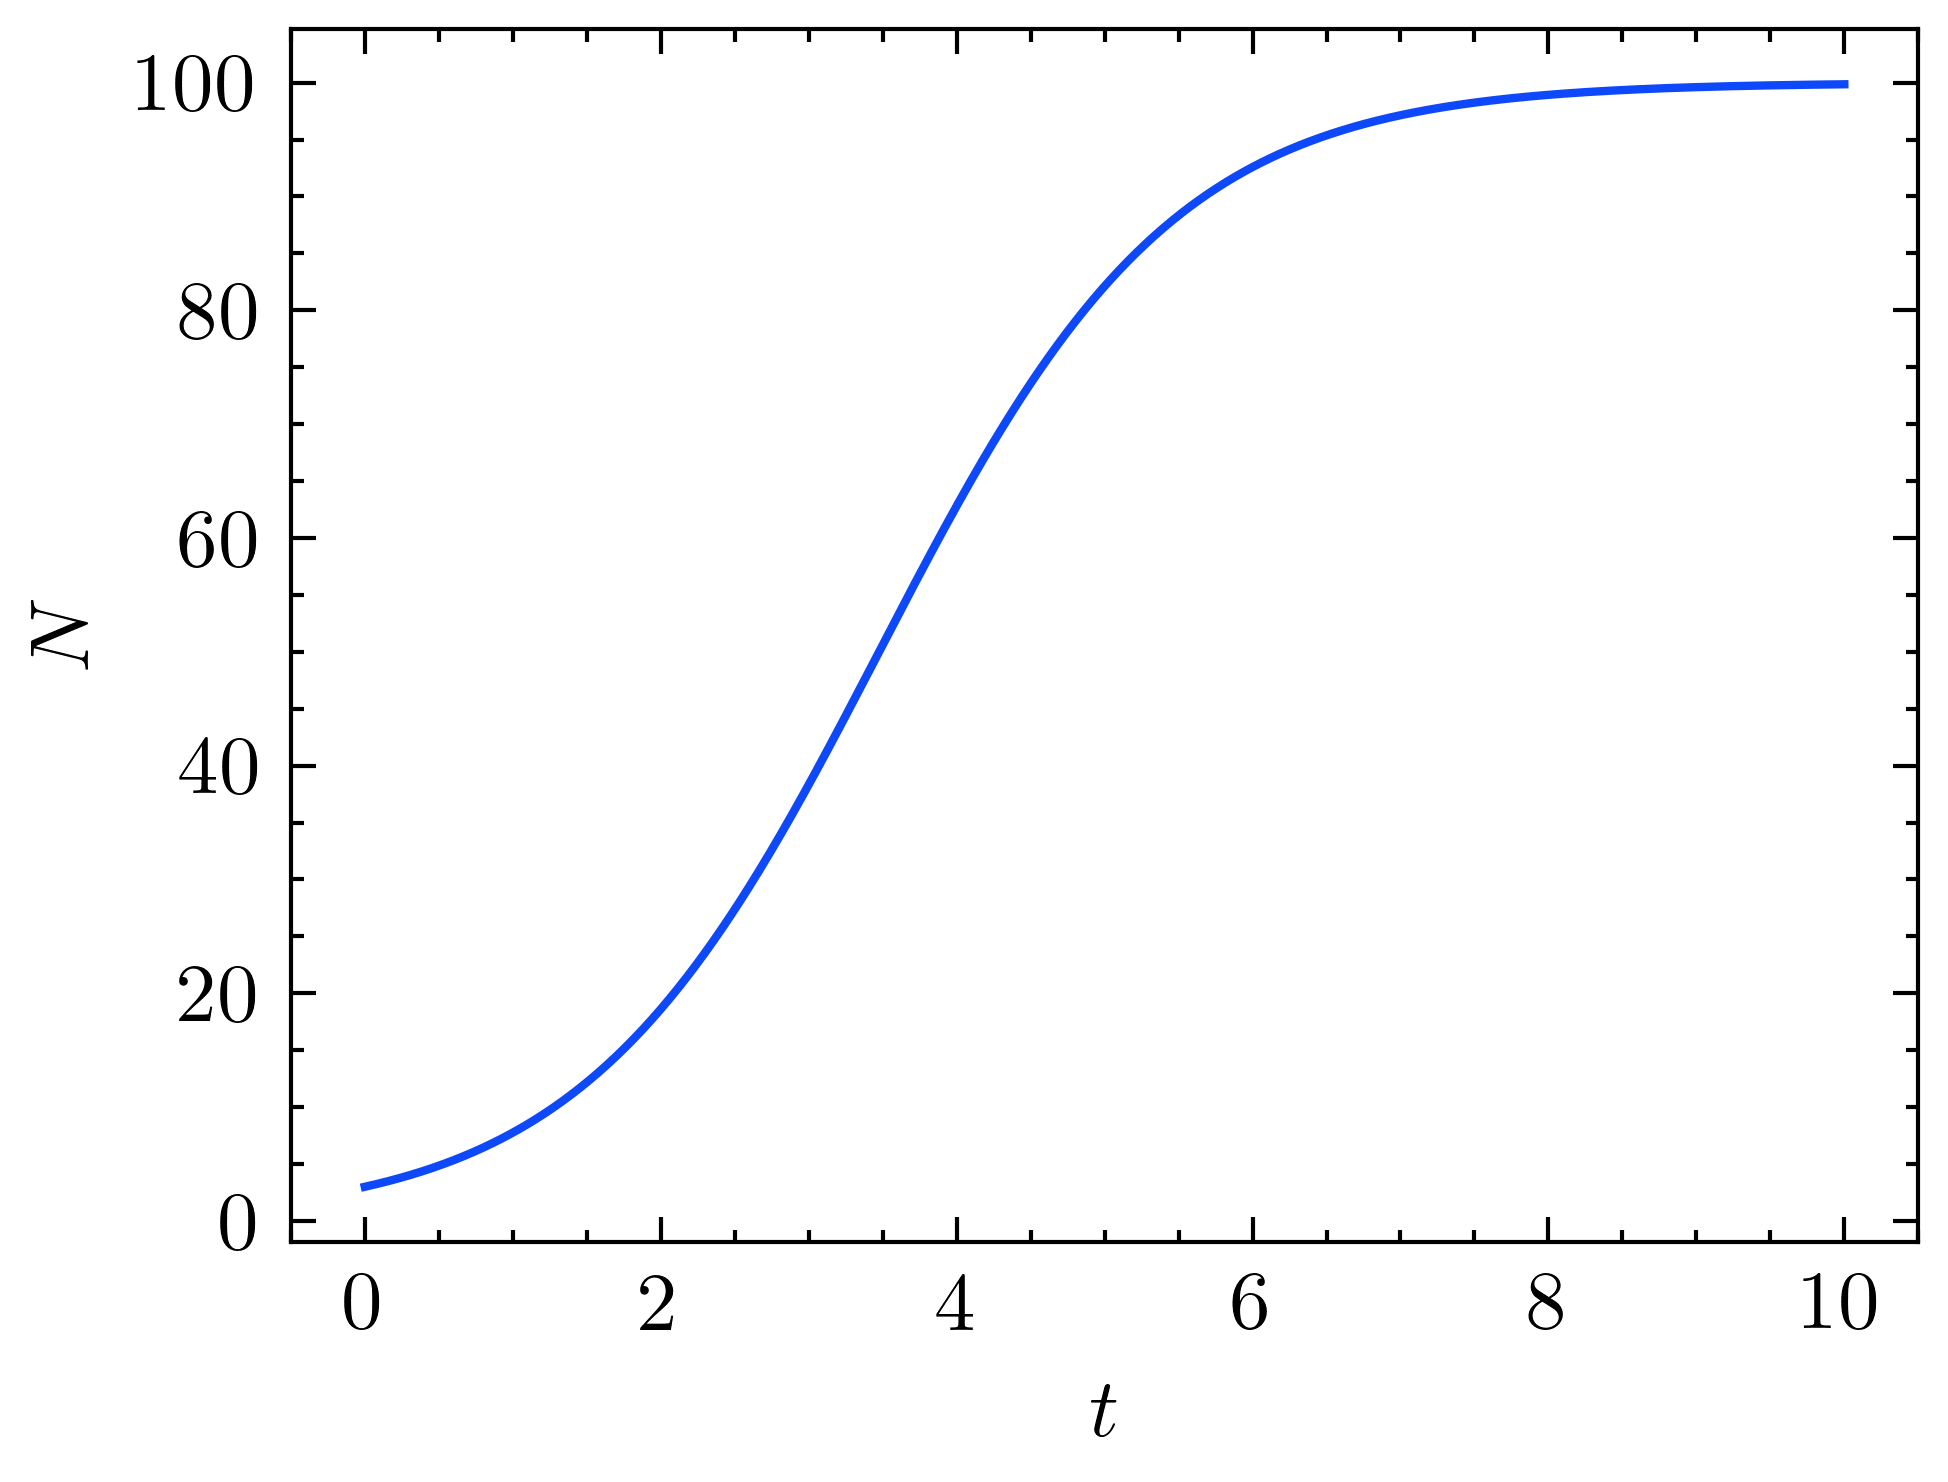

In [4]:
logistic = lambda t, N, r, K: r * N * (1 - N / K)
t_span = (0, 10)
y0 = [3]
r = 1
k = 100

sol = solve_ivp(logistic, t_span, y0, args=(r, k), max_step=0.01)
plot(sol, "logistic")

### Lotka-Volterra 竞争模型

$$
\frac{\mathrm{d} N_1}{\mathrm{d} t} = r_1 N_1 (1 - \frac{N_1}{K_1} - \alpha_{1,2} \frac{N_2}{K_1})
$$
$$
\frac{\mathrm{d} N_2}{\mathrm{d} t} = r_2 N_2 (1 - \frac{N_2}{K_2} - \alpha_{2,1} \frac{N_1}{K_2})
$$

$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = r_i N_i (1 - \frac{1}{K_i} \sum_{j} \alpha_{i,j} N_j)
$$

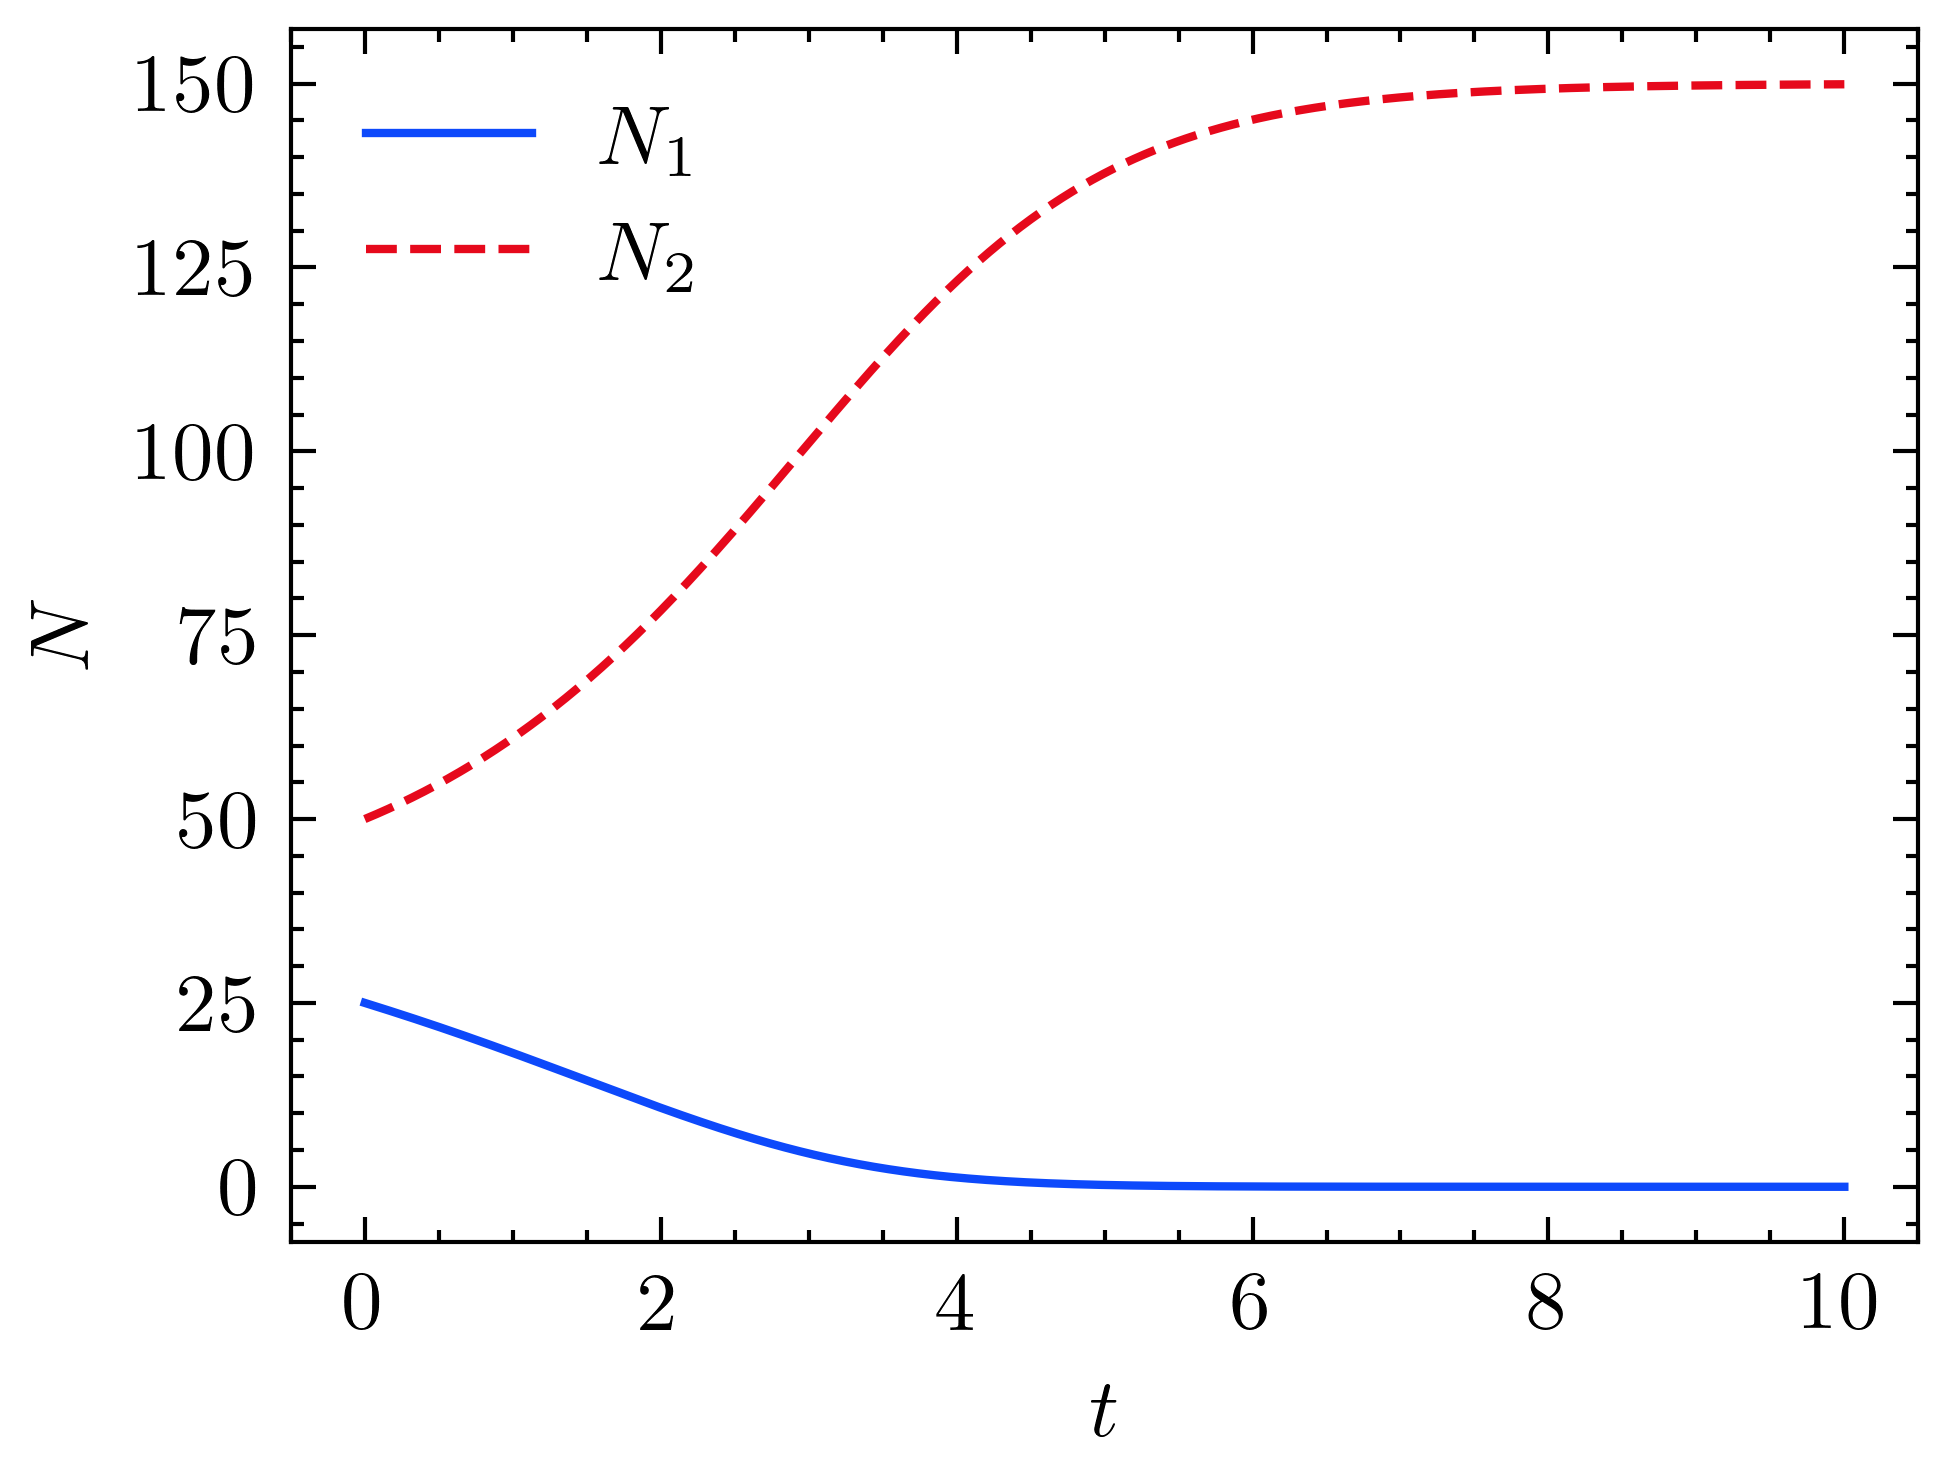

In [5]:
lvc = lambda i, t, N, r, K, alpha: r[i] * N[i] * (1 - np.dot(alpha[i], N) / K[i])

t_span = (0, 10)
y0 = (25, 50)
r = (1, 1)
k = (100, 150)
alpha = (
    [1, 2],
    [3, 1]
)

sol = solve_ivp(eqs(lvc, len(y0)), t_span, y0, args=(r, k, alpha), max_step=0.01)
plot(sol, "lotka-volterra-competition")

### Lotka-Volterra 捕食模型

$$
\frac{\mathrm{d} N_1}{\mathrm{d} t} = r_1 N_1 - \beta_{1,2} N_1 N_2
$$
$$
\frac{\mathrm{d} N_2}{\mathrm{d} t} = -r_2 N_2 + \beta_{2,1} N_1 N_2
$$

$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = N_i (r_i + \sum_{j} \beta_{i,j} N_j)
$$

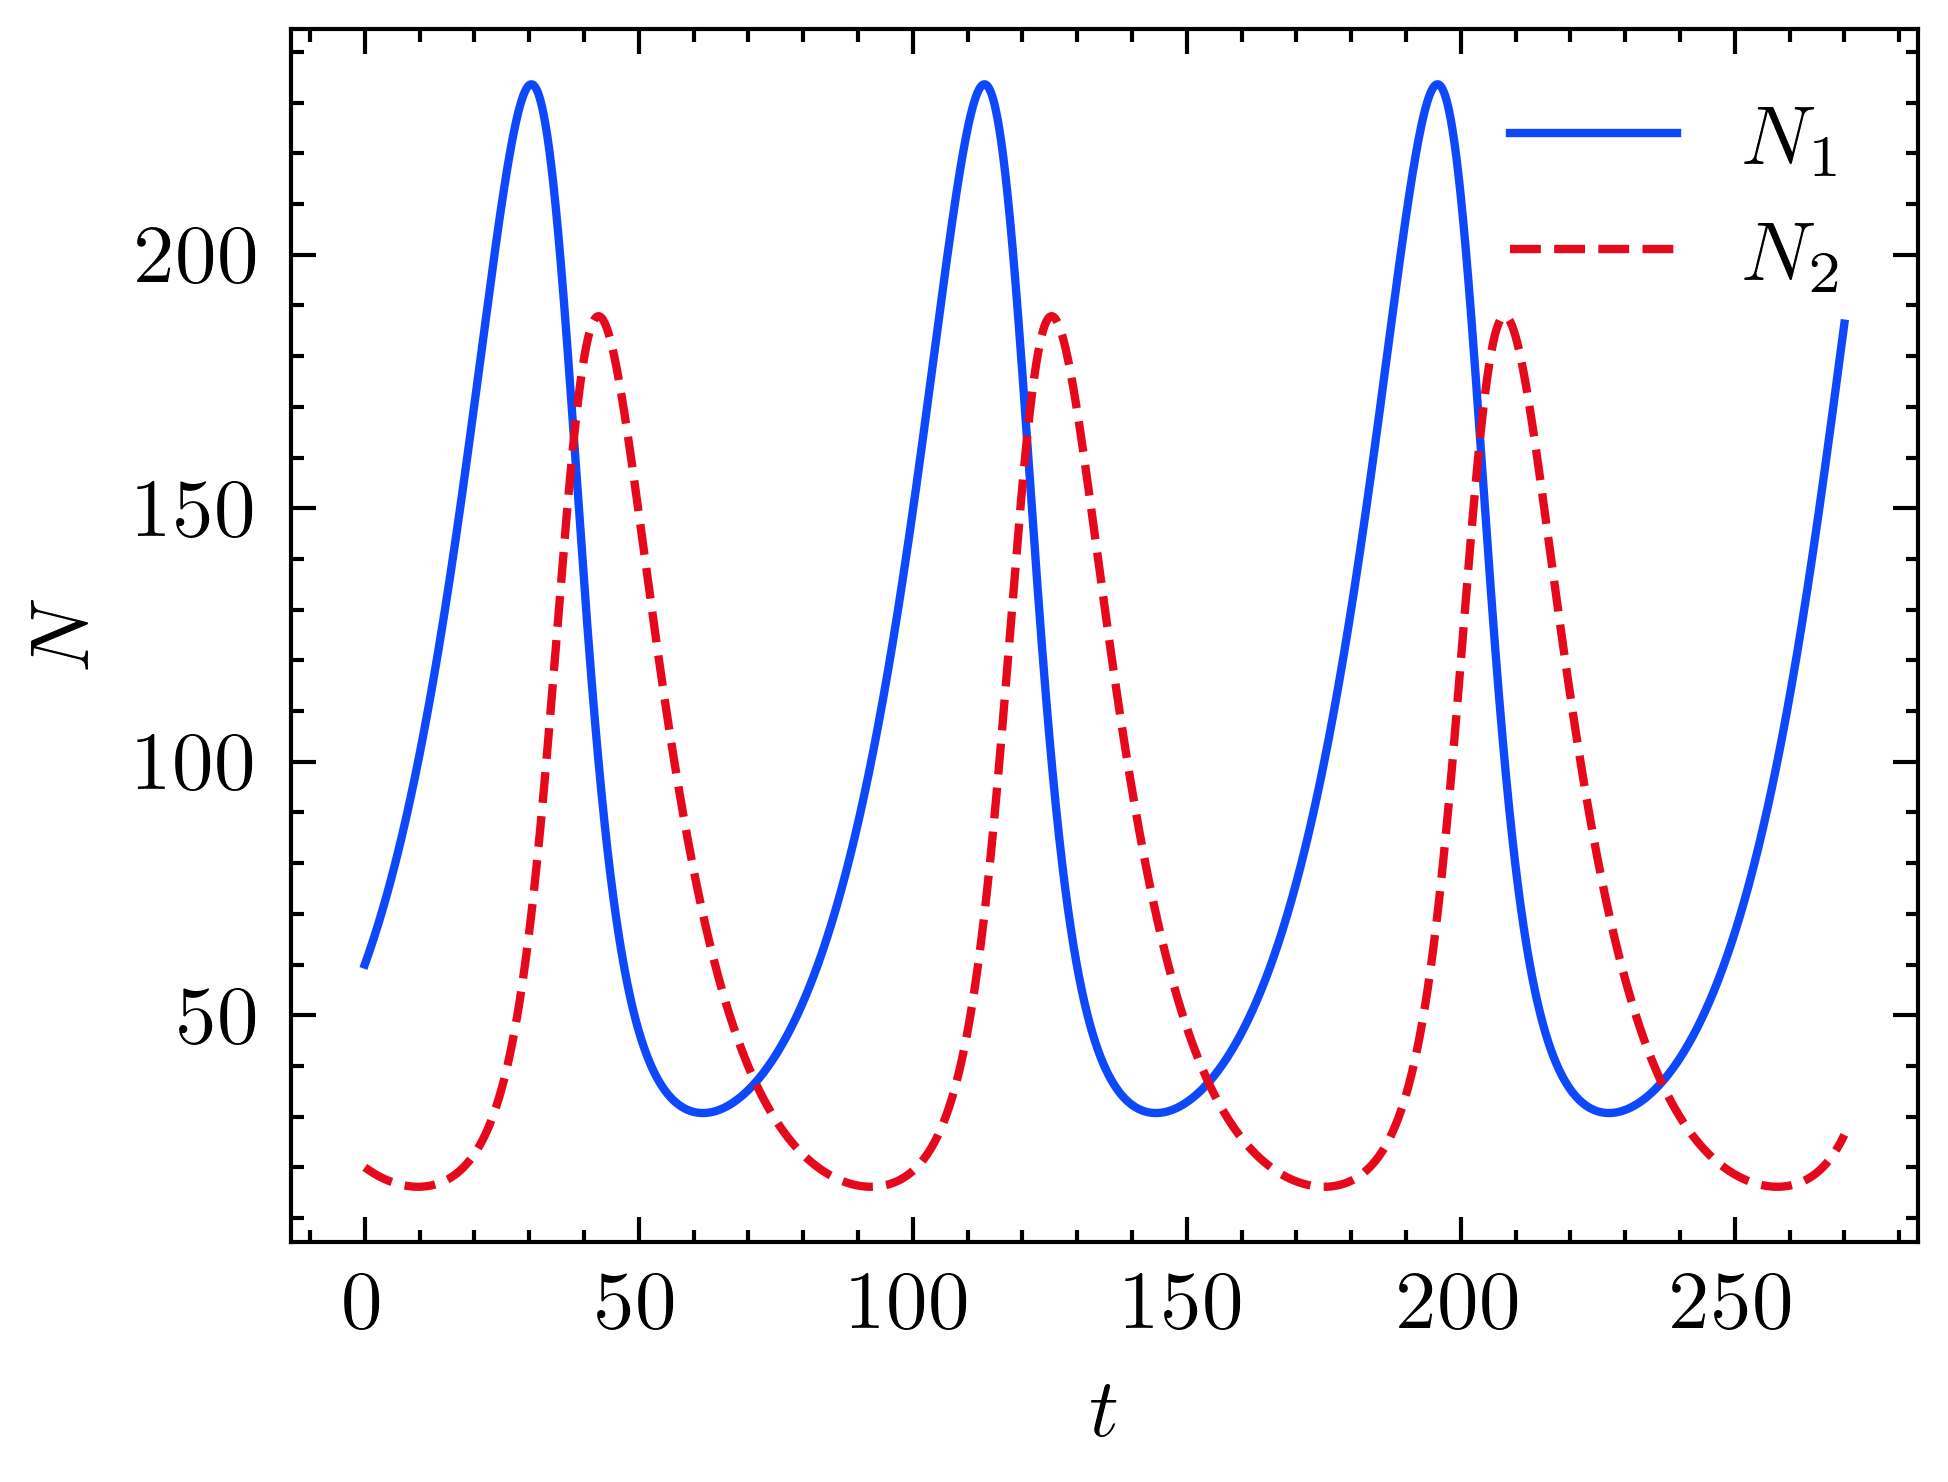

In [6]:
lvp = lambda i, t, N, r, beta: N[i] * (r[i] + np.dot(beta[i], N))

t_span = (0, 270)
y0 = [60, 20]
r = (0.07, -0.1)
beta = (
    [0, -0.001],
    [0.001, 0],
)

sol = solve_ivp(eqs(lvp, len(y0)), t_span, y0, args=(r, beta), max_step=0.01)
plot(sol, "lotka-volterra-predation")

### 综合模型

$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = N_i (1 - \frac{1}{K_i} \sum_{j} \alpha_{i,j} N_j) (r_i + \sum_{j} \beta_{i,j} N_j) + L_i(t)
$$

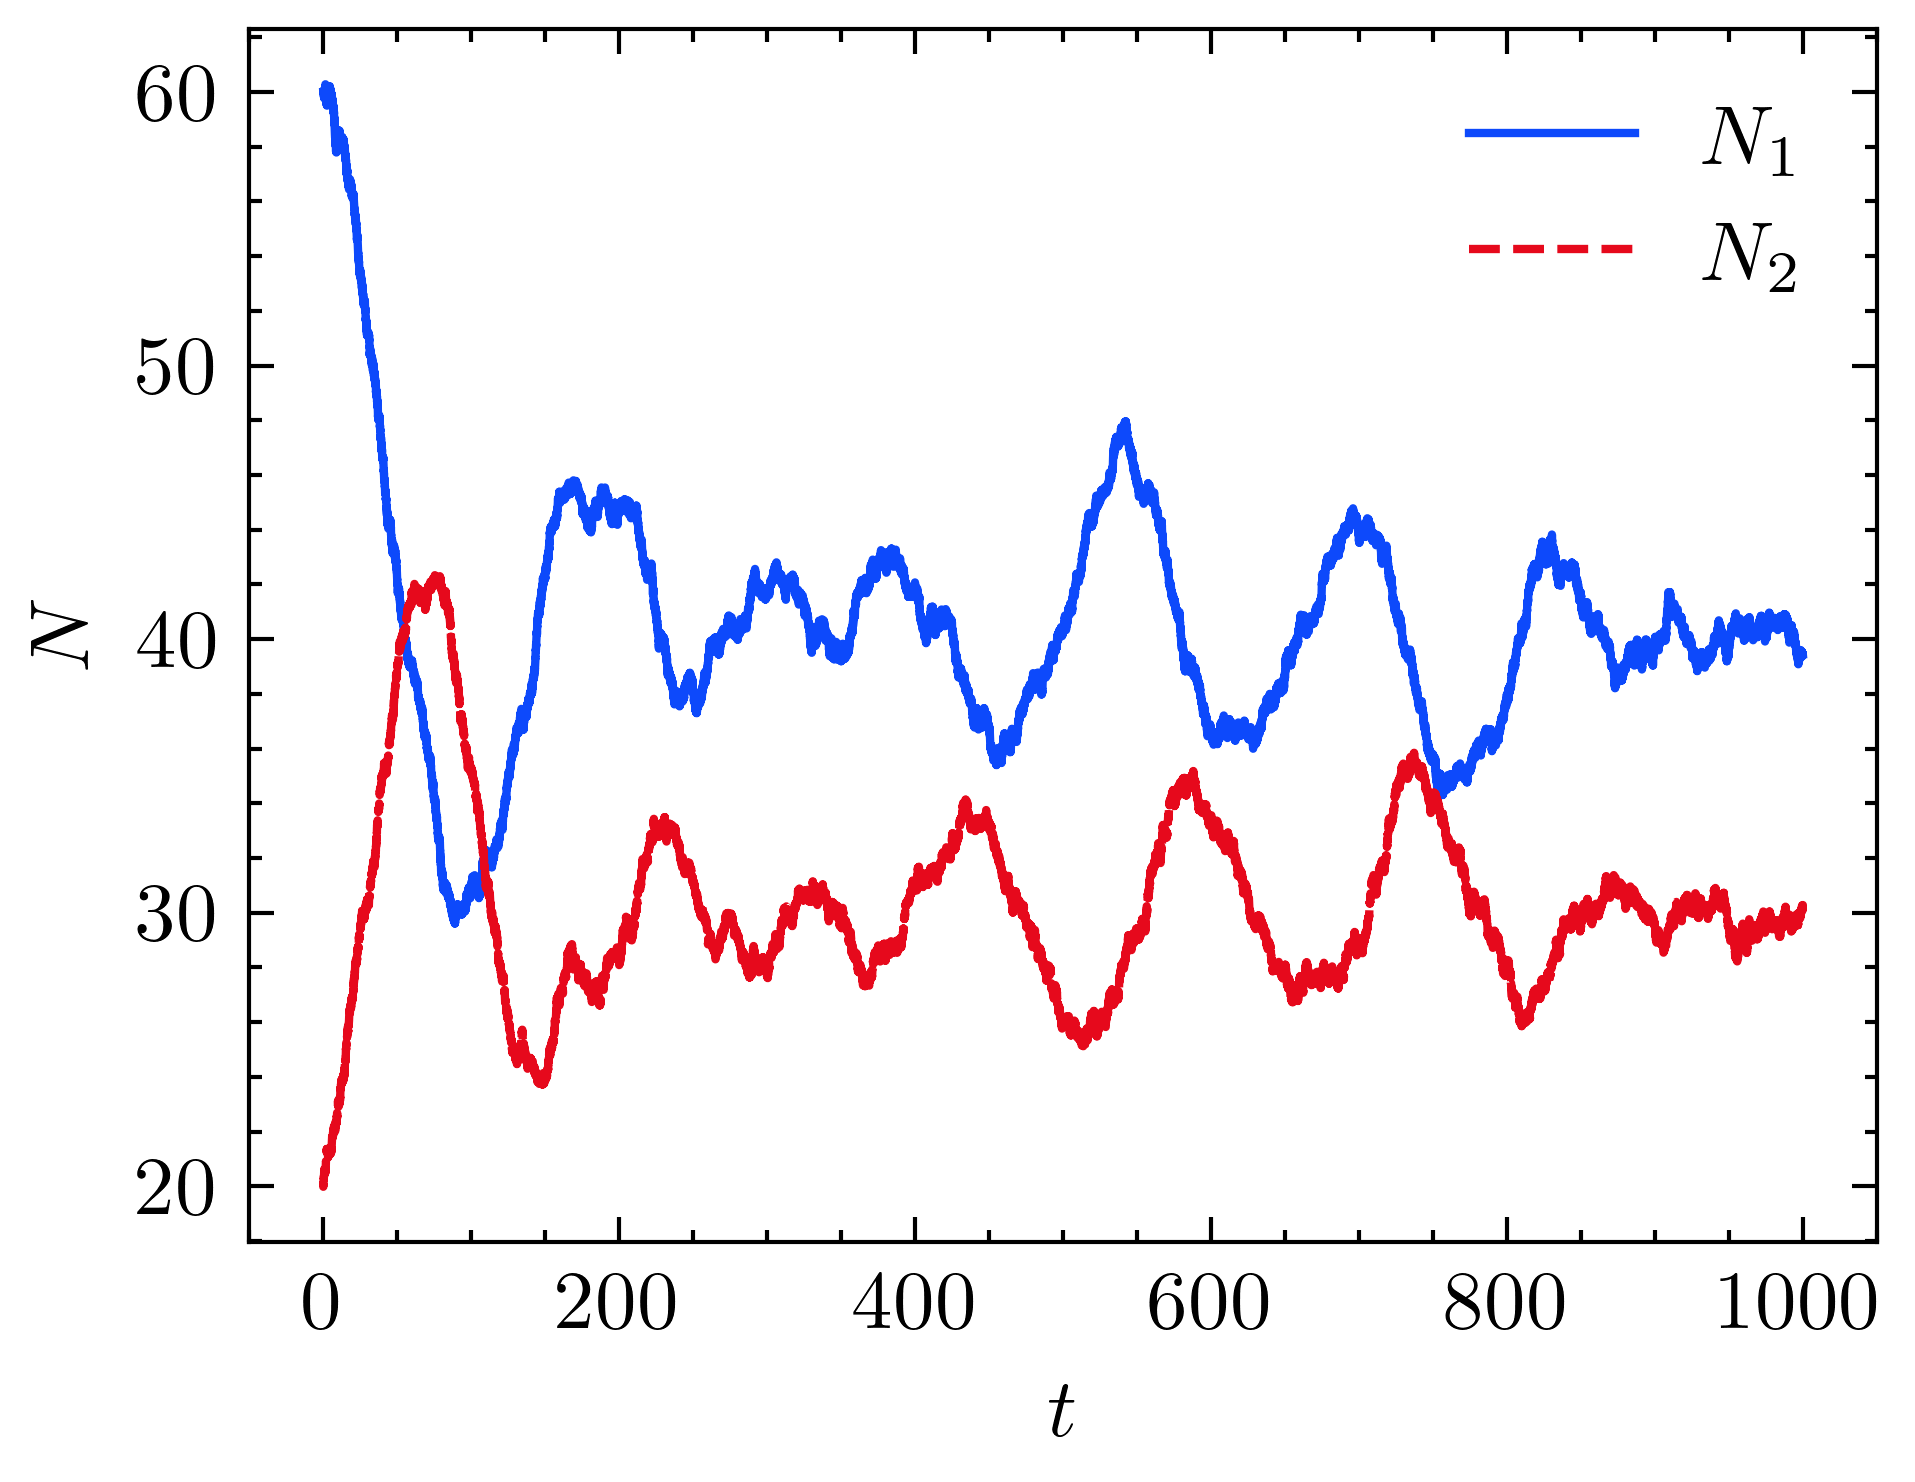

In [7]:
general = lambda i, t, N, r, K, alpha, beta, L: N[i] * (1 - np.dot(alpha[i], N) / K[i]) * (r[i] + np.dot(beta[i], N)) + L[i](t)

# TODO: more data
t_span = (0, 1000)
y0 = [60, 20]
r = (0.1, -0.1)
k = (100, 150)
alpha = (
    [1, 2],
    [3, 1]
)
beta = (
    [0, -0.001],
    [0.001, 0],
)
L = (lambda t: (random.random() - 0.5) * 10,) * 2

sol = solve_ivp(eqs(general, len(y0)), t_span, y0, args=(r, k, alpha, beta, L), max_step=0.01)
plot(sol, "general")